Функция для очистки группы duration_min

In [1]:
def clean_duration_group(group):
    q1, q3 = group["duration_min"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - iqr*1.5, q3 + iqr*1.5

    outlier_idx = group.index[(group["duration_min"] < lower) | (group["duration_min"] > upper)]
    
    for idx in outlier_idx:
        val = group.loc[idx, "duration_min"]
        fixed = None
        if lower < val < upper:
            fixed = val
        group.loc[idx, "duration_min"] = fixed
    
    return group

Чтение и чистка данных

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

    # Все данные нужных типов
df = pd.read_csv("bike_trips.csv")
df["station"] = df["station"].str.lower().str.strip()
df["duration_min"] = pd.to_numeric(df["duration_min"].str.strip().str.replace(" мин", "", regex=True))
df["start_time"] = pd.to_datetime(df["start_time"])

    # Отбор некорректных строк (ушло 1188)
df.drop_duplicates(inplace=True)    # 358 дубликатов удалено
df = df[df["duration_min"] > 0]     # 830 строк удалено в связи с некорректным значением duration_min
#df.dropna(inplace=True)     # 1189 строк удалено из-за недостатка данных (NaN), но в данной задаче нет смысла избавляться от NaN

Отдельные буферы для среднего прироста поездок в день/месяц

In [8]:
    # Сглаженный средний прирост кол-ва поездок в день
daily = (
    df.set_index("start_time")
      .groupby("station")
      .resample("D")
      .agg(trips=("trip_id", "count"))
      .reset_index()
)

daily["groups_rolling30"] = daily.groupby("station")["trips"].rolling(window=30, min_periods=7).sum().reset_index()["trips"]
daily["difference"] = daily.groupby("station")["groups_rolling30"].transform(lambda s: s.diff())

    # Средний прирост кол-ва поездок в месяц
monthly = (
    df.set_index("start_time")
        .groupby("station")
        .resample("ME")
        .agg(trips=("trip_id", "count"))
        .reset_index()
)
monthly["difference"] = monthly.groupby("station")["trips"].diff()

Отдельные буферы для среднего прироста часов езды в день/месяц

In [9]:
df_duration = df.copy()
df_duration = clean_duration_group(df_duration)
df_duration.dropna(subset="duration_min")

    # Сглаженный средний прирост часов езды в день

daily_duration = (
    df.set_index("start_time")
        .groupby("station")
        .resample("D")
        .agg(total_duration=("duration_min", "sum"))
        .reset_index()
)

daily_duration["groups_rolling30"] = daily_duration.groupby("station")["total_duration"].rolling(window=30, min_periods=7).sum().reset_index()["total_duration"]
daily_duration["difference"] = daily_duration.groupby("station")["groups_rolling30"].transform(lambda s: s.diff())

    # Средний прирост часов езды в месяц
monthly_duration = (
    df.set_index("start_time")
        .groupby("station")
        .resample("ME")
        .agg(total_duration=("duration_min", "sum"))
        .reset_index()
)

monthly_duration["difference"] = monthly_duration.groupby("station")["total_duration"].diff()

total_trips = df.groupby("station")["duration_min"].sum().sort_values(ascending=False)

ГРАФИК 1: Динамика по станциям

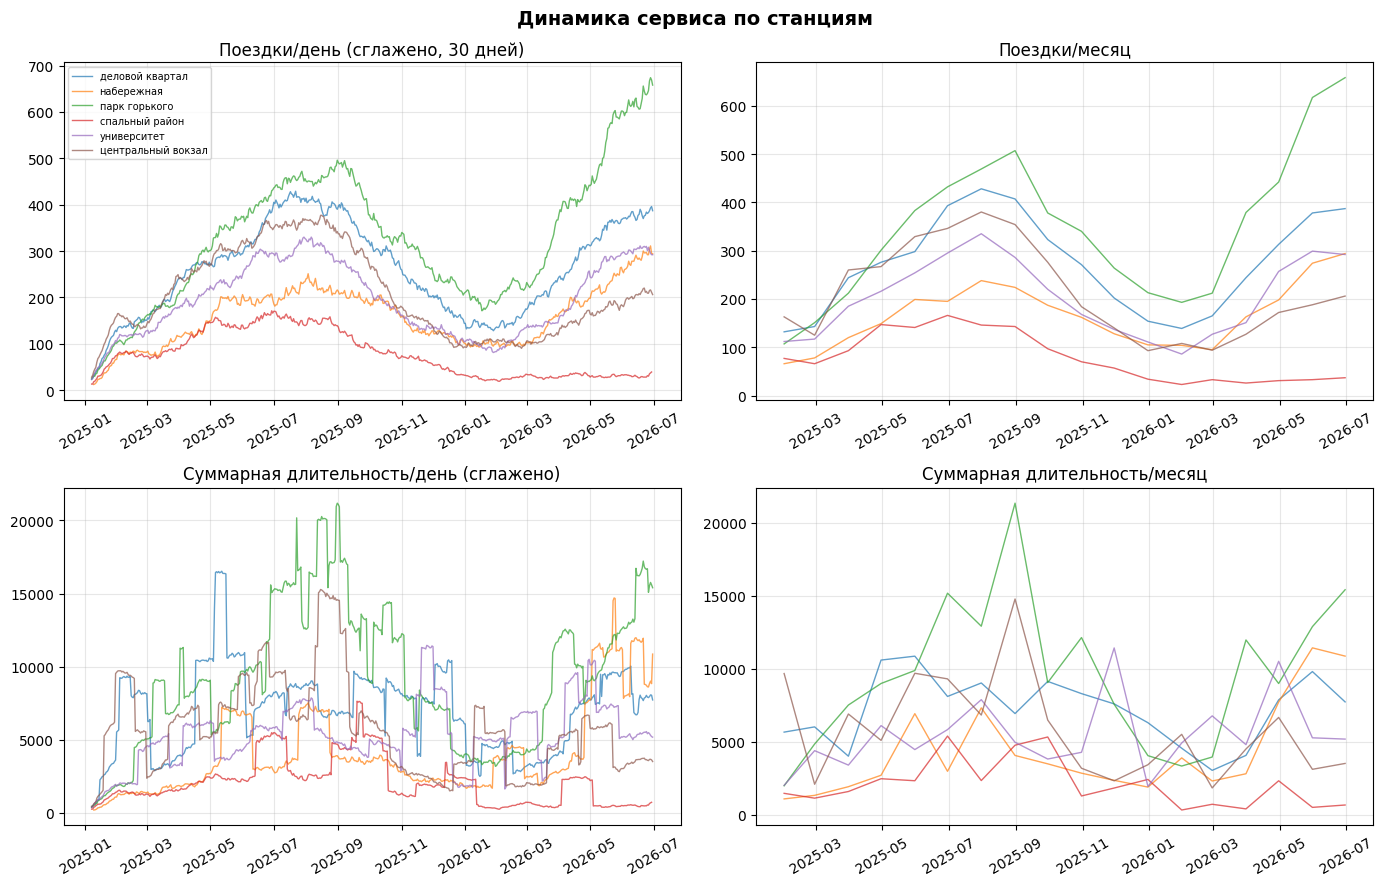

In [ ]:
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 9))

panels = [
    (daily,            "groups_rolling30",   "Поездки/день (сглажено, 30 дней)", axes1[0, 0]),
    (monthly,          "trips",              "Поездки/месяц",                    axes1[0, 1]),
    (daily_duration,   "groups_rolling30",   "Суммарная длительность/день (сглажено)", axes1[1, 0]),
    (monthly_duration, "total_duration",     "Суммарная длительность/месяц",     axes1[1, 1]),
]

for data, col, title, ax in panels:
    if col not in data.columns:
        print(f"Предупреждение: колонка '{col}' не найдена в данных для графика '{title}'")
        continue
    for station, group in data.groupby("station"):
        ax.plot(group["start_time"], group[col], label=station, linewidth=1, alpha=0.7)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

handles, labels = axes1[0, 0].get_legend_handles_labels()
if handles:
    axes1[0, 0].legend(fontsize=7, loc="upper left")

fig1.suptitle("Динамика сервиса по станциям", fontsize=14, fontweight="bold")
fig1.tight_layout()

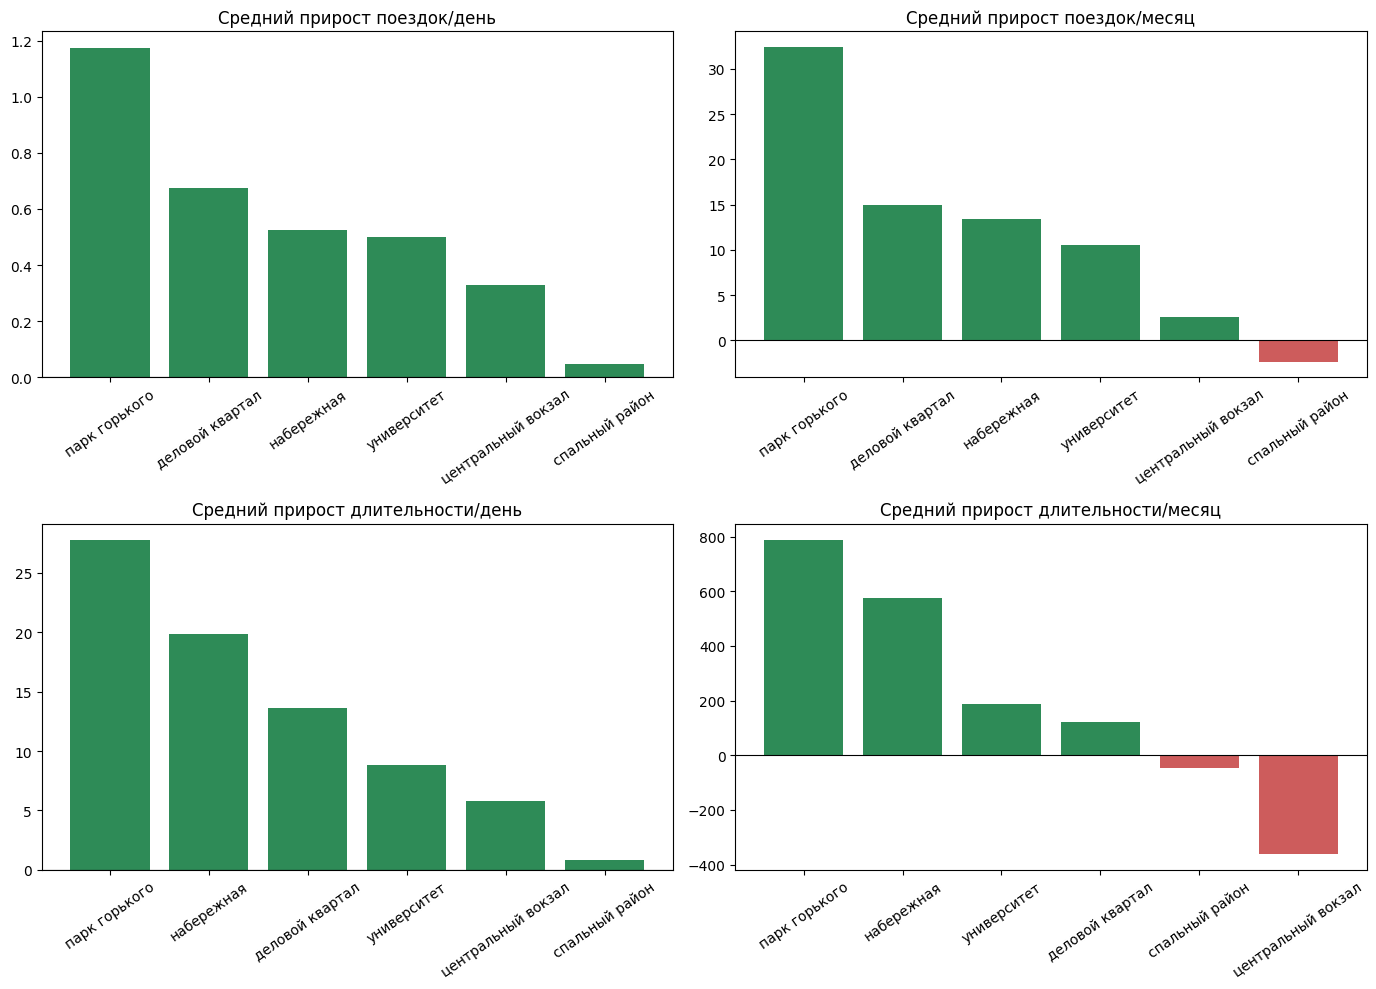

In [11]:
    # ГРАФИК 2: Тренды (средние приросты) для всех 4-х метрик
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))

# Данные для трендов: (DataFrame, колонка с приростом, подпись)
trend_data = [
    (daily,            "difference", "Средний прирост поездок/день"),
    (monthly,          "difference", "Средний прирост поездок/месяц"),
    (daily_duration,   "difference", "Средний прирост длительности/день"),
    (monthly_duration, "difference", "Средний прирост длительности/месяц"),
]

for ax, (data, col, title) in zip(axes2.flat, trend_data):
    # Средний прирост по каждой станции
    trend = data.groupby("station")[col].mean().sort_values(ascending=False)
    # Цвет: зелёный для положительного тренда, красный для отрицательного
    colors = ["seagreen" if v > 0 else "indianred" for v in trend.values]
    ax.bar(trend.index, trend.values, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)

fig2.tight_layout()


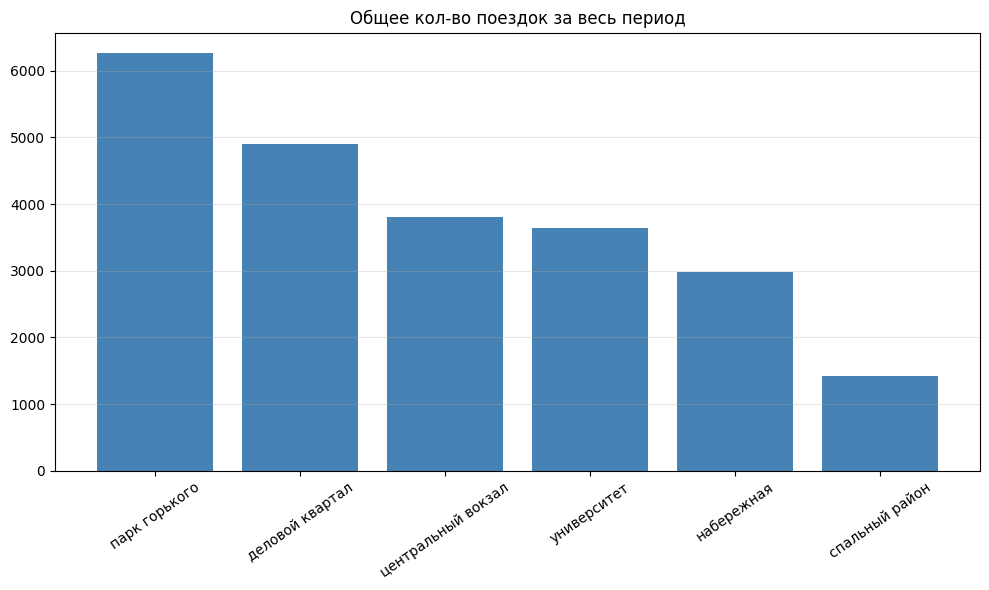

In [13]:
    # ГРАФИК 3: Общее количество поездок по станциям
fig3, ax3 = plt.subplots(figsize=(10, 6))

# Суммарное число поездок за весь период
totals = daily.groupby("station")["trips"].sum().sort_values(ascending=False)

ax3.bar(totals.index, totals.values, color="steelblue")
ax3.set_title("Общее кол-во поездок за весь период")
ax3.tick_params(axis="x", rotation=35)
ax3.grid(axis="y", alpha=0.3)

fig3.tight_layout()